In [ ]:
# ============================================================
# CELL 1 — Mount Drive + install packages
# ============================================================

from google.colab import drive, files
drive.mount("/content/drive")

!pip -q install speciesnet timm torch torchvision scikit-learn pandas matplotlib pillow requests tqdm

import os, re, json, math, time, random, subprocess
from pathlib import Path
from io import BytesIO

import requests
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

from sklearn.metrics import (
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 77.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.6/97.6 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 956.3/956.3 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 118.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 43

In [ ]:
# ============================================================
# CELL 2 — Project config
# ============================================================

PROJECT_DIR = Path("/content/drive/MyDrive/speciesnet_experiment_iNat_bottom20")
IMG_DIR = PROJECT_DIR / "images"
CSV_DIR = PROJECT_DIR / "csv"
CKPT_DIR = PROJECT_DIR / "checkpoints"
PLOT_DIR = PROJECT_DIR / "plots"
RESULT_DIR = PROJECT_DIR / "results"
JSON_DIR = PROJECT_DIR / "json"

for d in [IMG_DIR, CSV_DIR, CKPT_DIR, PLOT_DIR, RESULT_DIR, JSON_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DATE_AFTER = "2025-04-01"

# Upload lila_bottom20_targets.json to Colab when prompted.
TARGET_JSON_PATH = JSON_DIR / "lila_bottom20_targets.json"

# Uses JSON count_train as base training count per species.
ADDED_IMAGES_PER_SPECIES = [2, 8, 16]

VAL_PER_CLASS = 20
TEST_PER_CLASS = 50

# To keep notebook manageable. Increase later if needed.
MAX_SPECIES = 40

# Number of iNat images to try downloading per species.
MAX_IMAGES_PER_SPECIES = 150

BATCH_SIZE = 16
NUM_EPOCHS = 8
LR = 1e-3
WEIGHT_DECAY = 1e-4
IMAGE_SIZE = 384
NUM_WORKERS = 2

In [ ]:
# ============================================================
# CELL 3 — Load JSON target species
# ============================================================

if not TARGET_JSON_PATH.exists():
    print("Upload lila_bottom20_targets.json")
    uploaded = files.upload()
    for fname in uploaded:
        if fname.endswith(".json"):
            shutil_path = JSON_DIR / fname
            with open(shutil_path, "wb") as f:
                f.write(uploaded[fname])
            TARGET_JSON_PATH = shutil_path
            break

with open(TARGET_JSON_PATH, "r") as f:
    raw_targets = json.load(f)

def clean_label(s):
    return re.sub(r"[^a-zA-Z0-9_]+", "_", str(s).strip().lower()).strip("_")

def make_query_name(row):
    if row.get("genus") and row.get("species"):
        return f"{row['genus']} {row['species']}"
    return row.get("common_name")

targets = []
for row in raw_targets:
    query_name = make_query_name(row)
    common_name = row.get("common_name")

    if query_name is None or common_name is None:
        continue

    targets.append({
        "label": clean_label(common_name),
        "query_name": query_name,
        "common_name": common_name,
        "genus": row.get("genus"),
        "species": row.get("species"),
        "count_train": int(row.get("count_train", 1)),
        "count_validation": int(row.get("count_validation", 0)),
        "count_test": int(row.get("count_test", 0)),
    })

targets = targets[:MAX_SPECIES]

targets_df = pd.DataFrame(targets)
targets_df.to_csv(CSV_DIR / "target_species_from_json.csv", index=False)
display(targets_df.head())
print("Number of target species:", len(targets_df))

,label,query_name,common_name,genus,species,count_train,count_validation,count_test
0,anteater_family,Anteater Family,Anteater Family,None,None,1,0,0
1,atherurus_species,Atherurus Species,Atherurus Species,Atherurus,None,1,0,0
2,austral_blackbird,Curaeus curaeus,Austral Blackbird,Curaeus,curaeus,1,0,0
3,barn_swallow,Hirundo rustica,Barn Swallow,Hirundo,rustica,1,1,0
4,black_and_white_warbler,Mniotilta varia,Black-and-white Warbler,Mniotilta,varia,1,3,0


Number of target species: 40


In [ ]:
# ============================================================
# CELL 4 — iNaturalist query helpers
# ============================================================

INAT_BASE = "https://api.inaturalist.org/v1"

def resolve_taxon_id(query_name):
    r = requests.get(
        f"{INAT_BASE}/taxa",
        params={"q": query_name, "rank": "species", "per_page": 10},
        timeout=30,
    )
    r.raise_for_status()
    results = r.json().get("results", [])

    if not results:
        return None

    # Prefer exact scientific name match.
    q = query_name.lower()
    for t in results:
        if t.get("name", "").lower() == q:
            return {
                "taxon_id": t["id"],
                "inat_name": t.get("name"),
                "inat_common_name": t.get("preferred_common_name"),
                "rank": t.get("rank"),
            }

    # Otherwise take first species-rank result.
    t = results[0]
    return {
        "taxon_id": t["id"],
        "inat_name": t.get("name"),
        "inat_common_name": t.get("preferred_common_name"),
        "rank": t.get("rank"),
    }

def query_photo_urls(taxon_id, max_images):
    urls = []
    page = 1

    while len(urls) < max_images:
        params = {
            "taxon_id": taxon_id,
            "photos": "true",
            "quality_grade": "research",
            "d1": DATE_AFTER,
            "order_by": "created_at",
            "order": "desc",
            "per_page": 200,
            "page": page,
        }

        r = requests.get(f"{INAT_BASE}/observations", params=params, timeout=60)
        r.raise_for_status()
        results = r.json().get("results", [])

        if not results:
            break

        for obs in results:
            for photo in obs.get("photos", []):
                url = photo.get("url")
                if url:
                    url = url.replace("square.", "medium.").replace("small.", "medium.")
                    urls.append(url)
                    if len(urls) >= max_images:
                        break
            if len(urls) >= max_images:
                break

        page += 1
        time.sleep(0.25)

    return urls[:max_images]

def download_image(url, out_path):
    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        img = Image.open(BytesIO(r.content)).convert("RGB")
        img.save(out_path)
        return True
    except Exception:
        return False

In [ ]:
# ============================================================
# CELL 5 — Resolve JSON species to iNaturalist taxa
# Safe to rerun.
# ============================================================

resolved_rows = []

for row in tqdm(targets, desc="resolving taxa"):
    resolved = resolve_taxon_id(row["query_name"])

    if resolved is None:
        resolved_rows.append({**row, "resolved": False})
        continue

    resolved_rows.append({
        **row,
        **resolved,
        "resolved": True,
    })

resolved_df = pd.DataFrame(resolved_rows)
resolved_df.to_csv(CSV_DIR / "resolved_inat_taxa.csv", index=False)

display(resolved_df)
print("Resolved:", resolved_df["resolved"].sum(), "/", len(resolved_df))

resolving taxa:   0%|          | 0/40 [00:00<?, ?it/s]

,label,query_name,common_name,genus,species,count_train,count_validation,count_test,resolved,taxon_id,inat_name,inat_common_name,rank
0,anteater_family,Anteater Family,Anteater Family,None,None,1,0,0,False,NaN,NaN,NaN,NaN
1,atherurus_species,Atherurus Species,Atherurus Species,Atherurus,None,1,0,0,False,NaN,NaN,NaN,NaN
2,austral_blackbird,Curaeus curaeus,Austral Blackbird,Curaeus,curaeus,1,0,0,True,10307.0,Curaeus curaeus,Austral Blackbird,species
3,barn_swallow,Hirundo rustica,Barn Swallow,Hirundo,rustica,1,1,0,True,11901.0,Hirundo rustica,Barn Swallow,species
4,black_and_white_warbler,Mniotilta varia,Black-and-white Warbler,Mniotilta,varia,1,3,0,True,10286.0,Mniotilta varia,Black-and-white Warbler,species
5,black_billed_thrush,Turdus ignobilis,Black-billed Thrush,Turdus,ignobilis,1,0,0,True,980029.0,Turdus ignobilis,Black-billed Thrush,species
6,black_headed_wagtail,Motacilla feldegg,Black-headed Wagtail,Motacilla,feldegg,1,0,0,False,NaN,NaN,NaN,NaN
7,blue_faced_honeyeater,Entomyzon cyanotis,Blue-faced Honeyeater,Entomyzon,cyanotis,1,0,0,True,12659.0,Entomyzon cyanotis,Blue-faced Honeyeater,species
8,broad_billed_motmot,Electron platyrhynchum,Broad-billed Motmot,Electron,platyrhynchum,1,0,0,True,2154.0,Electron platyrhynchum,Broad-billed Motmot,species
9,brotogeris_species,Brotogeris Species,Brotogeris Species,Brotogeris,None,1,0,0,False,NaN,NaN,NaN,NaN


Resolved: 29 / 40


In [ ]:
# ============================================================
# CELL 6 — Download/cache iNaturalist images
# Safe to rerun after disconnect.
# ============================================================

resolved_df = pd.read_csv(CSV_DIR / "resolved_inat_taxa.csv")
resolved_df = resolved_df[resolved_df["resolved"] == True].copy()

records = []

for _, row in resolved_df.iterrows():
    label = row["label"]
    taxon_id = int(row["taxon_id"])

    class_dir = IMG_DIR / label
    class_dir.mkdir(parents=True, exist_ok=True)

    existing = list(class_dir.glob("*.jpg"))
    print(f"\n{label}: existing={len(existing)}, taxon_id={taxon_id}")

    if len(existing) < MAX_IMAGES_PER_SPECIES:
        urls = query_photo_urls(taxon_id, MAX_IMAGES_PER_SPECIES)
        print(f"Found {len(urls)} URLs")

        for i, url in enumerate(tqdm(urls, desc=f"downloading {label}")):
            out_path = class_dir / f"{label}_{i:04d}.jpg"
            if out_path.exists():
                continue
            download_image(url, out_path)

    for p in sorted(class_dir.glob("*.jpg")):
        records.append({
            "path": str(p),
            "label": label,
            "query_name": row["query_name"],
            "common_name": row["common_name"],
            "taxon_id": taxon_id,
            "source": "inat_after_2025_04_01",
            "base_count_train": int(row["count_train"]),
        })

df_all = pd.DataFrame(records).drop_duplicates("path").reset_index(drop=True)
df_all.to_csv(CSV_DIR / "all_downloaded_metadata.csv", index=False)

print("\nDownloaded image counts:")
print(df_all["label"].value_counts())


austral_blackbird: existing=150, taxon_id=10307

barn_swallow: existing=150, taxon_id=11901

black_and_white_warbler: existing=150, taxon_id=10286

black_billed_thrush: existing=150, taxon_id=980029

blue_faced_honeyeater: existing=150, taxon_id=12659

broad_billed_motmot: existing=150, taxon_id=2154

brown_titi_monkey: existing=33, taxon_id=926855
Found 33 URLs


downloading brown_titi_monkey:   0%|          | 0/33 [00:00<?, ?it/s]


california_chipmunk: existing=51, taxon_id=225744
Found 51 URLs


downloading california_chipmunk:   0%|          | 0/51 [00:00<?, ?it/s]


canyon_towhee: existing=150, taxon_id=145289

cascade_golden_mantled_ground_squirrel: existing=150, taxon_id=180009

cassin_s_kingbird: existing=150, taxon_id=16779

cassin_s_sparrow: existing=150, taxon_id=73175

coal_tit: existing=150, taxon_id=144823

common_dunnart: existing=78, taxon_id=40219
Found 78 URLs


...


greater_yellowlegs: existing=150, taxon_id=3892

green_anole: existing=150, taxon_id=36514

grey_goshawk: existing=150, taxon_id=1583020

grey_honeyeater: existing=3, taxon_id=12670
Found 3 URLs


downloading grey_honeyeater:   0%|          | 0/3 [00:00<?, ?it/s]


hoary_bamboo_rat: existing=1, taxon_id=45027
Found 1 URLs


downloading hoary_bamboo_rat:   0%|          | 0/1 [00:00<?, ?it/s]


hooded_siskin: existing=150, taxon_id=145316

horned_screamer: existing=150, taxon_id=6908

indian_giant_squirrel: existing=150, taxon_id=46030

Downloaded image counts:
label
austral_blackbird                         150
barn_swallow                              150
black_and_white_warbler                   150
black_billed_thrush                       150
blue_faced_honeyeater                     150
broad_billed_motmot                       150
canyon_towhee                             150
cassin_s_kingbird                         150
cascade_golden_mantled_ground_squirrel    150
cassin_s_sparrow                          150
coal_tit                                  150
domestic_water_buffalo                    150
crested_tit                               150
indian_giant_squirrel                     150
horned_screamer                           150
european_bee_eater                        150
faucon_p_lerin                            150
gila_monster                             

In [ ]:
# ============================================================
# CELL 7 — Build train/val/test CSVs
# Experiments:
# E2  = base count_train + 2 images/species
# E8  = base count_train + 8 images/species
# E16 = base count_train + 16 images/species
# Validation/test use the same held-out iNat images.
# ============================================================

df_all = pd.read_csv(CSV_DIR / "all_downloaded_metadata.csv")

def build_splits_for_added_n(df_all, added_n, val_per_class=20, test_per_class=50):
    train_parts = []
    val_parts = []
    test_parts = []
    kept = []
    dropped = []

    for label, sub in df_all.groupby("label"):
        sub = sub.sample(frac=1, random_state=SEED).reset_index(drop=True)

        base_n = int(sub["base_count_train"].iloc[0])
        train_n = base_n + added_n
        needed = train_n + val_per_class + test_per_class

        if len(sub) < needed:
            dropped.append({
                "label": label,
                "available": len(sub),
                "needed": needed,
                "base_n": base_n,
                "added_n": added_n,
            })
            continue

        train = sub.iloc[:train_n]
        val = sub.iloc[train_n:train_n + val_per_class]
        test = sub.iloc[train_n + val_per_class:train_n + val_per_class + test_per_class]

        train_parts.append(train)
        val_parts.append(val)
        test_parts.append(test)
        kept.append(label)

    train_df = pd.concat(train_parts).sample(frac=1, random_state=SEED).reset_index(drop=True)
    val_df = pd.concat(val_parts).sample(frac=1, random_state=SEED).reset_index(drop=True)
    test_df = pd.concat(test_parts).sample(frac=1, random_state=SEED).reset_index(drop=True)

    return train_df, val_df, test_df, kept, pd.DataFrame(dropped)

split_summaries = []

for added_n in ADDED_IMAGES_PER_SPECIES:
    exp_name = f"E{added_n}"

    train_df, val_df, test_df, kept, dropped_df = build_splits_for_added_n(
        df_all,
        added_n=added_n,
        val_per_class=VAL_PER_CLASS,
        test_per_class=TEST_PER_CLASS,
    )

    train_df.to_csv(CSV_DIR / f"{exp_name}_train.csv", index=False)
    val_df.to_csv(CSV_DIR / f"{exp_name}_val.csv", index=False)
    test_df.to_csv(CSV_DIR / f"{exp_name}_test.csv", index=False)
    dropped_df.to_csv(CSV_DIR / f"{exp_name}_dropped_species.csv", index=False)

    print(f"\n{exp_name}")
    print("train:", len(train_df), "val:", len(val_df), "test:", len(test_df))
    print("classes kept:", len(kept))
    print("train counts:")
    print(train_df["label"].value_counts().head())

    split_summaries.append({
        "experiment": exp_name,
        "added_images_per_species": added_n,
        "num_classes": len(kept),
        "num_train": len(train_df),
        "num_val": len(val_df),
        "num_test": len(test_df),
        "num_dropped_species": len(dropped_df),
    })

pd.DataFrame(split_summaries).to_csv(CSV_DIR / "split_summary.csv", index=False)
display(pd.DataFrame(split_summaries))


E2
train: 72 val: 480 test: 1200
classes kept: 24
train counts:
label
barn_swallow         3
grey_goshawk         3
canyon_towhee        3
austral_blackbird    3
cassin_s_sparrow     3
Name: count, dtype: int64

E8
train: 207 val: 460 test: 1150
classes kept: 23
train counts:
label
greater_yellowlegs    9
barn_swallow          9
cassin_s_kingbird     9
coal_tit              9
green_anole           9
Name: count, dtype: int64

E16
train: 391 val: 460 test: 1150
classes kept: 23
train counts:
label
austral_blackbird          17
black_and_white_warbler    17
barn_swallow               17
green_anole                17
horned_screamer            17
Name: count, dtype: int64


,experiment,added_images_per_species,num_classes,num_train,num_val,num_test,num_dropped_species
0,E2,2,24,72,480,1200,5
1,E8,8,23,207,460,1150,6
2,E16,16,23,391,460,1150,6


In [ ]:
# ============================================================
# CELL 8 — Dataset/model/metric definitions
# ============================================================

train_tfms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class WildlifeDataset(Dataset):
    def __init__(self, df, label_to_idx, tfms):
        self.df = df.reset_index(drop=True)
        self.label_to_idx = label_to_idx
        self.tfms = tfms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        x = self.tfms(img)
        y = self.label_to_idx[row["label"]]
        return x, y

class FrozenSpeciesNetHead(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.backbone = timm.create_model(
            "tf_efficientnetv2_m.in21k",
            pretrained=True,
            num_classes=0,
            global_pool="avg",
        )

        for param in self.backbone.parameters():
            param.requires_grad = False

        self.classifier = nn.Sequential(
            nn.Dropout(0.25),
            nn.Linear(self.backbone.num_features, num_classes),
        )

    def forward(self, x):
        with torch.no_grad():
            feats = self.backbone(x)
        return self.classifier(feats)

@torch.no_grad()
def predict(model, loader):
    model.eval()
    y_true, y_pred = [], []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy().tolist()
        y_true.extend(yb.numpy().tolist())
        y_pred.extend(preds)

    return np.array(y_true), np.array(y_pred)

def compute_speciesnet_metrics(y_true, y_pred, idx_to_label):
    overall_weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    overall_macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    excluded = {"blank", "human", "vehicle"}
    species_indices = [i for i, lab in idx_to_label.items() if lab not in excluded]
    species_mask = np.isin(y_true, species_indices) | np.isin(y_pred, species_indices)

    species_level_weighted_f1 = f1_score(
        y_true[species_mask],
        y_pred[species_mask],
        labels=species_indices,
        average="weighted",
        zero_division=0,
    ) if species_mask.sum() > 0 else np.nan

    labels = list(idx_to_label.values())
    if "blank" in labels:
        blank_idx = labels.index("blank")
        blank_f1 = f1_score(y_true, y_pred, labels=[blank_idx], average="macro", zero_division=0)
    else:
        blank_f1 = np.nan

    return {
        "overall_weighted_f1": overall_weighted_f1,
        "species_level_weighted_f1": species_level_weighted_f1,
        "overall_macro_f1": overall_macro_f1,
        "blank_f1": blank_f1,
    }

def per_class_f1_table(y_true, y_pred, idx_to_label, train_counts):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(idx_to_label.keys()),
        zero_division=0,
    )

    rows = []
    for i, label in idx_to_label.items():
        rows.append({
            "label": label,
            "train_count": int(train_counts.get(label, 0)),
            "test_support": int(support[i]),
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i],
        })

    return pd.DataFrame(rows).sort_values(["train_count", "f1"])

def aggregate_binary_confusion_matrix(y_true, y_pred, num_classes):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    correct = y_true == y_pred
    incorrect = y_true != y_pred

    TP = int(correct.sum())
    FP = int(incorrect.sum())
    FN = int(incorrect.sum())
    TN = int((correct.sum() * (num_classes - 1)) + (incorrect.sum() * (num_classes - 2)))

    return np.array([[TP, FP], [FN, TN]])

In [ ]:
# ============================================================
# CELL 9 — Resumable fine-tuning
# ============================================================

def train_resumable(experiment_name):
    train_df = pd.read_csv(CSV_DIR / f"{experiment_name}_train.csv")
    val_df = pd.read_csv(CSV_DIR / f"{experiment_name}_val.csv")

    labels = sorted(train_df["label"].unique())
    label_to_idx = {lab: i for i, lab in enumerate(labels)}
    idx_to_label = {i: lab for lab, i in label_to_idx.items()}

    train_ds = WildlifeDataset(train_df, label_to_idx, train_tfms)
    val_ds = WildlifeDataset(val_df, label_to_idx, eval_tfms)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)

    model = FrozenSpeciesNetHead(num_classes=len(labels)).to(DEVICE)

    optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()

    latest_ckpt = CKPT_DIR / f"{experiment_name}_latest.pt"
    best_ckpt = CKPT_DIR / f"{experiment_name}_best.pt"
    history_path = RESULT_DIR / f"{experiment_name}_training_history.csv"

    start_epoch = 1
    best_val_macro_f1 = -1
    history = []

    if latest_ckpt.exists():
        print(f"Resuming from {latest_ckpt}")
        ckpt = torch.load(latest_ckpt, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        start_epoch = ckpt["epoch"] + 1
        best_val_macro_f1 = ckpt["best_val_macro_f1"]

        if history_path.exists():
            history = pd.read_csv(history_path).to_dict("records")

    for epoch in range(start_epoch, NUM_EPOCHS + 1):
        model.train()
        total_loss = 0.0

        for xb, yb in tqdm(train_loader, desc=f"{experiment_name} epoch {epoch}/{NUM_EPOCHS}"):
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)

        train_loss = total_loss / len(train_ds)

        val_true, val_pred = predict(model, val_loader)
        val_metrics = compute_speciesnet_metrics(val_true, val_pred, idx_to_label)

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }

        history.append(row)
        pd.DataFrame(history).to_csv(history_path, index=False)
        print(row)

        if val_metrics["overall_macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = val_metrics["overall_macro_f1"]
            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "label_to_idx": label_to_idx,
                "idx_to_label": idx_to_label,
                "best_val_macro_f1": best_val_macro_f1,
            }, best_ckpt)

        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "label_to_idx": label_to_idx,
            "idx_to_label": idx_to_label,
            "best_val_macro_f1": best_val_macro_f1,
        }, latest_ckpt)

    print(f"Done training {experiment_name}")

In [ ]:
# ============================================================
# CELL 10 — Train E2/E8/E16
# Resumes automatically from latest checkpoint if interrupted.
# ============================================================

for exp_name in [f"E{n}" for n in ADDED_IMAGES_PER_SPECIES]:
    train_resumable(exp_name)

E2 epoch 1/8:   0%|          | 0/5 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 3.471553855472141, 'val_overall_weighted_f1': 0.09687258912172578, 'val_species_level_weighted_f1': 0.09687258912172578, 'val_overall_macro_f1': 0.09687258912172579, 'val_blank_f1': nan}


E2 epoch 2/8:   0%|          | 0/5 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': 2.53754014439053, 'val_overall_weighted_f1': 0.1962584268106355, 'val_species_level_weighted_f1': 0.1962584268106355, 'val_overall_macro_f1': 0.19625842681063546, 'val_blank_f1': nan}


E2 epoch 3/8:   0%|          | 0/5 [00:00<?, ?it/s]

...

{'epoch': 6, 'train_loss': 0.7798646493336124, 'val_overall_weighted_f1': 0.5621519046291978, 'val_species_level_weighted_f1': 0.5621519046291978, 'val_overall_macro_f1': 0.5621519046291977, 'val_blank_f1': nan}


E16 epoch 7/8:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 7, 'train_loss': 0.6544133055850369, 'val_overall_weighted_f1': 0.6029288084257355, 'val_species_level_weighted_f1': 0.6029288084257355, 'val_overall_macro_f1': 0.6029288084257355, 'val_blank_f1': nan}


E16 epoch 8/8:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 8, 'train_loss': 0.6249323004042097, 'val_overall_weighted_f1': 0.5945657664863941, 'val_species_level_weighted_f1': 0.5945657664863941, 'val_overall_macro_f1': 0.594565766486394, 'val_blank_f1': nan}
Done training E16


In [ ]:
# # ============================================================
# # OPTIONAL RESET CELL — Only run if you want to delete checkpoints
# # ============================================================

# for exp_name in [f"E{n}" for n in ADDED_IMAGES_PER_SPECIES]:
#     for suffix in ["latest", "best"]:
#         path = CKPT_DIR / f"{exp_name}_{suffix}.pt"
#         if path.exists():
#             print("Deleting", path)
#             path.unlink()

#     history_path = RESULT_DIR / f"{exp_name}_training_history.csv"
#     if history_path.exists():
#         print("Deleting", history_path)
#         history_path.unlink()

Deleting /content/drive/MyDrive/speciesnet_experiment_iNat_bottom20/checkpoints/E2_latest.pt
Deleting /content/drive/MyDrive/speciesnet_experiment_iNat_bottom20/checkpoints/E2_best.pt
Deleting /content/drive/MyDrive/speciesnet_experiment_iNat_bottom20/results/E2_training_history.csv
Deleting /content/drive/MyDrive/speciesnet_experiment_iNat_bottom20/checkpoints/E8_latest.pt
Deleting /content/drive/MyDrive/speciesnet_experiment_iNat_bottom20/checkpoints/E8_best.pt
Deleting /content/drive/MyDrive/speciesnet_experiment_iNat_bottom20/results/E8_training_history.csv
Deleting /content/drive/MyDrive/speciesnet_experiment_iNat_bottom20/checkpoints/E16_latest.pt
Deleting /content/drive/MyDrive/speciesnet_experiment_iNat_bottom20/checkpoints/E16_best.pt
Deleting /content/drive/MyDrive/speciesnet_experiment_iNat_bottom20/results/E16_training_history.csv


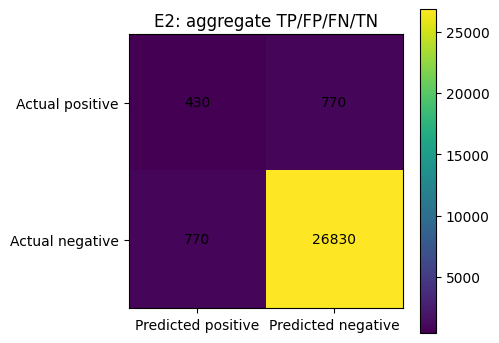

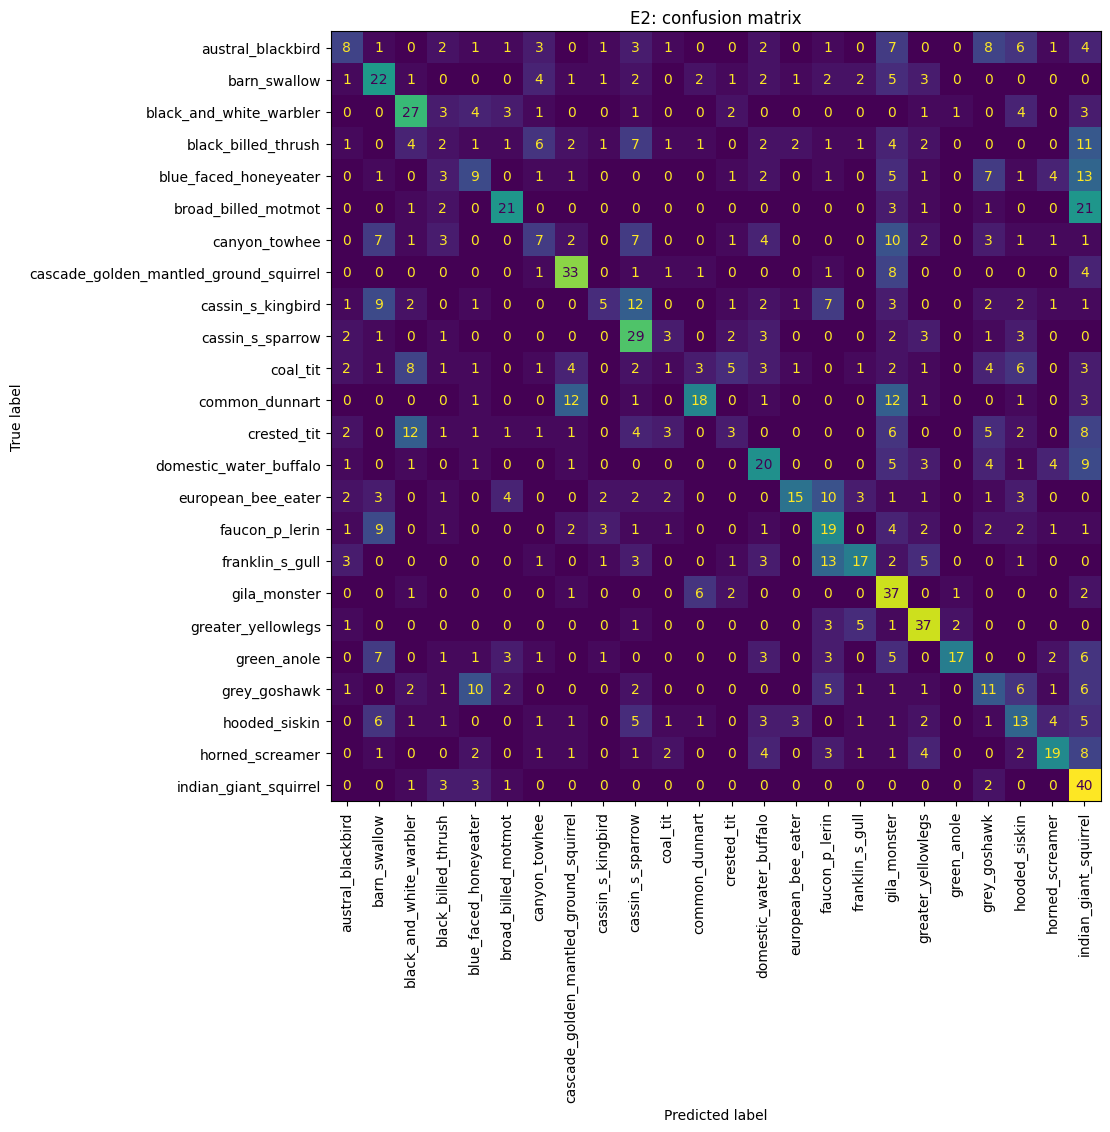

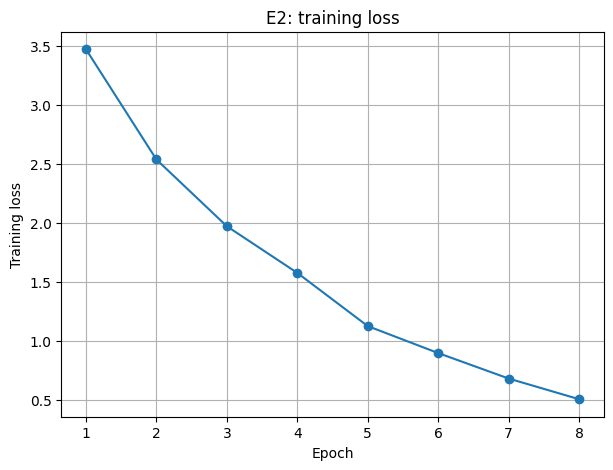

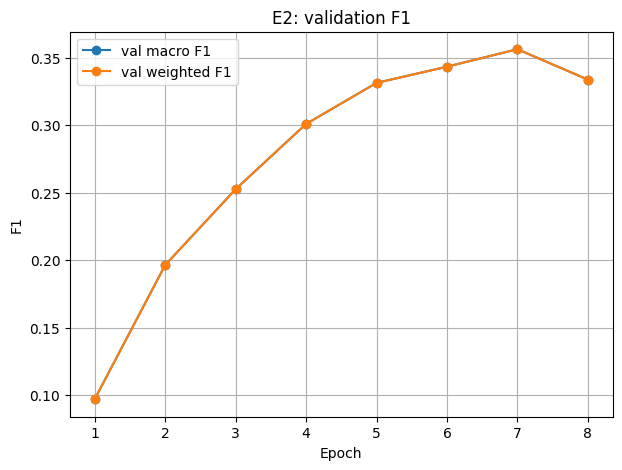

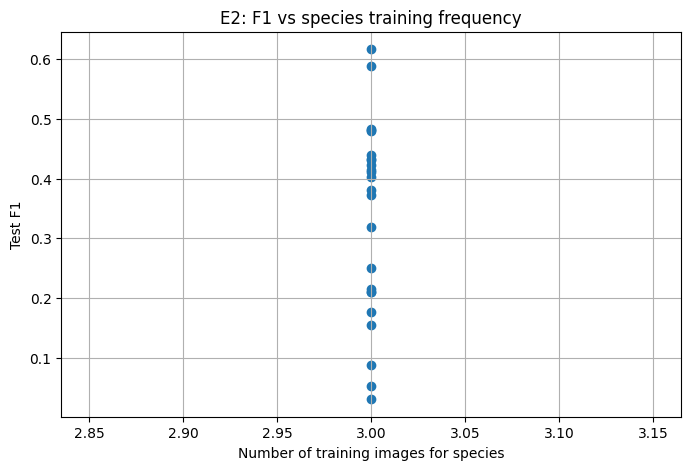

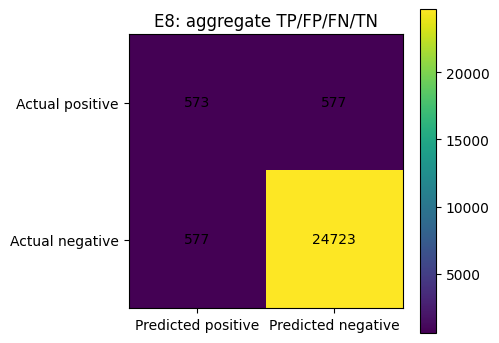

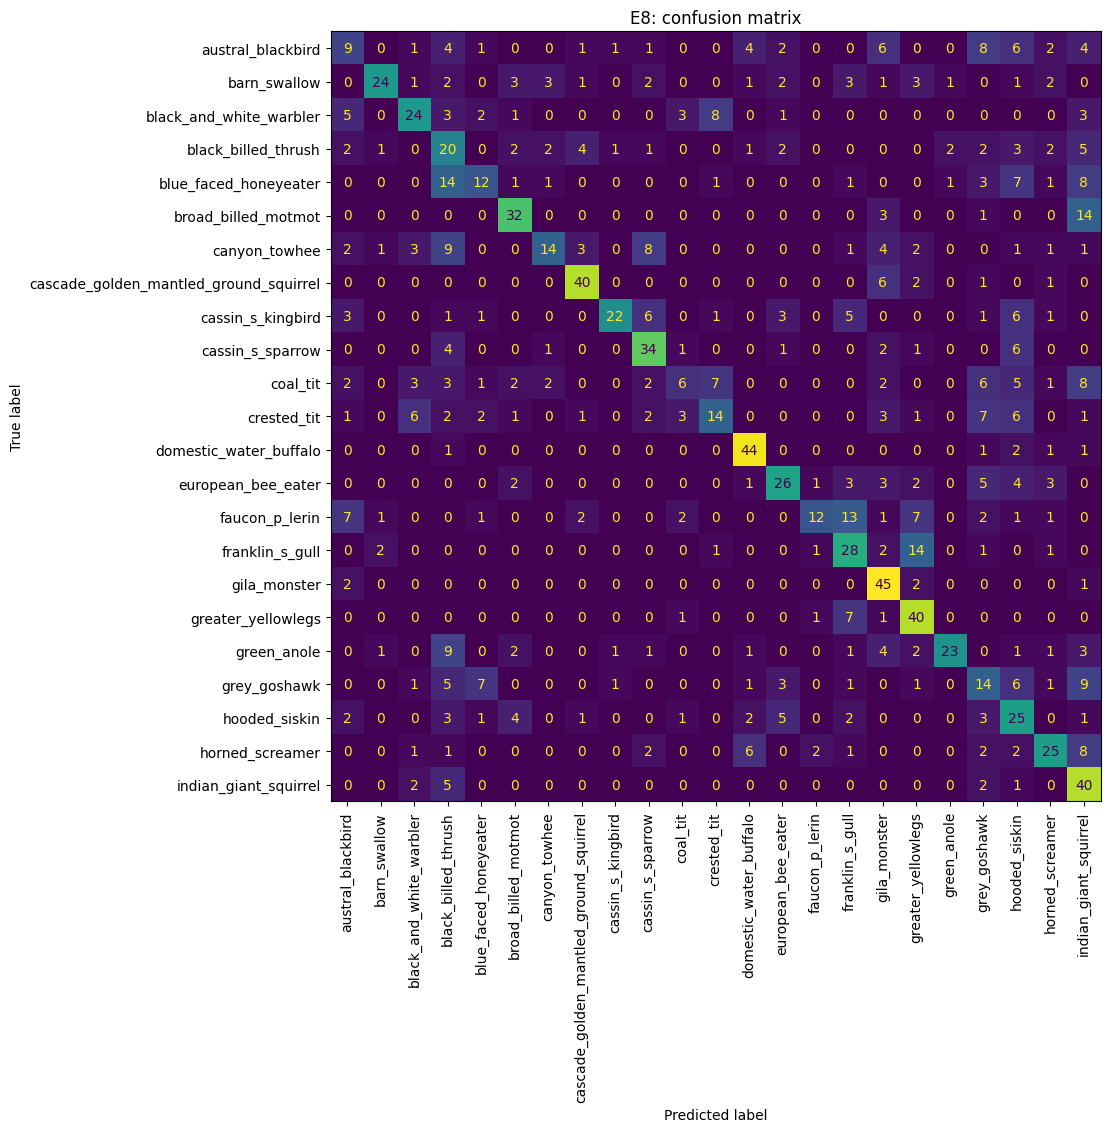

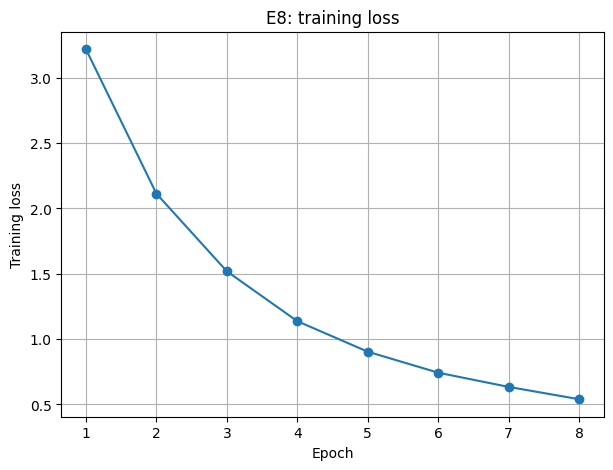

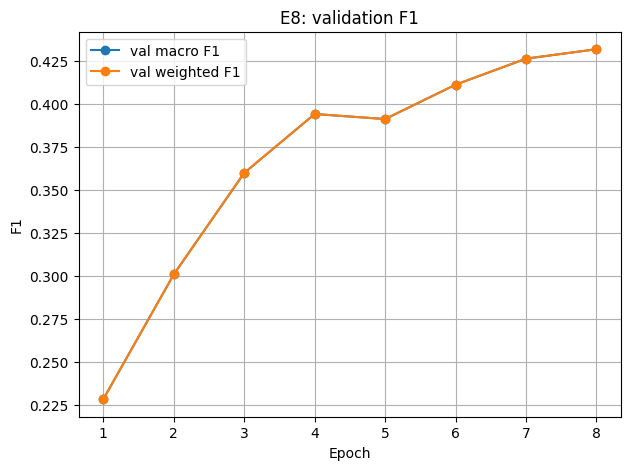

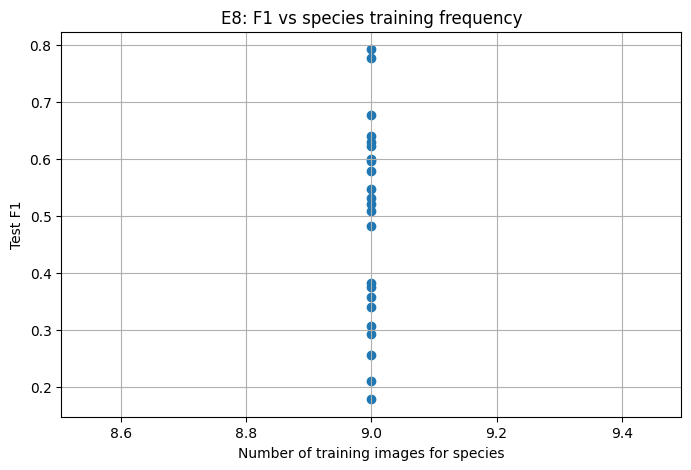

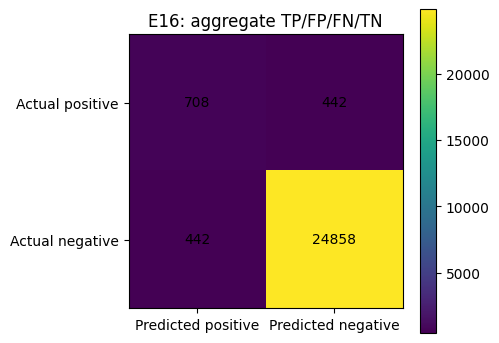

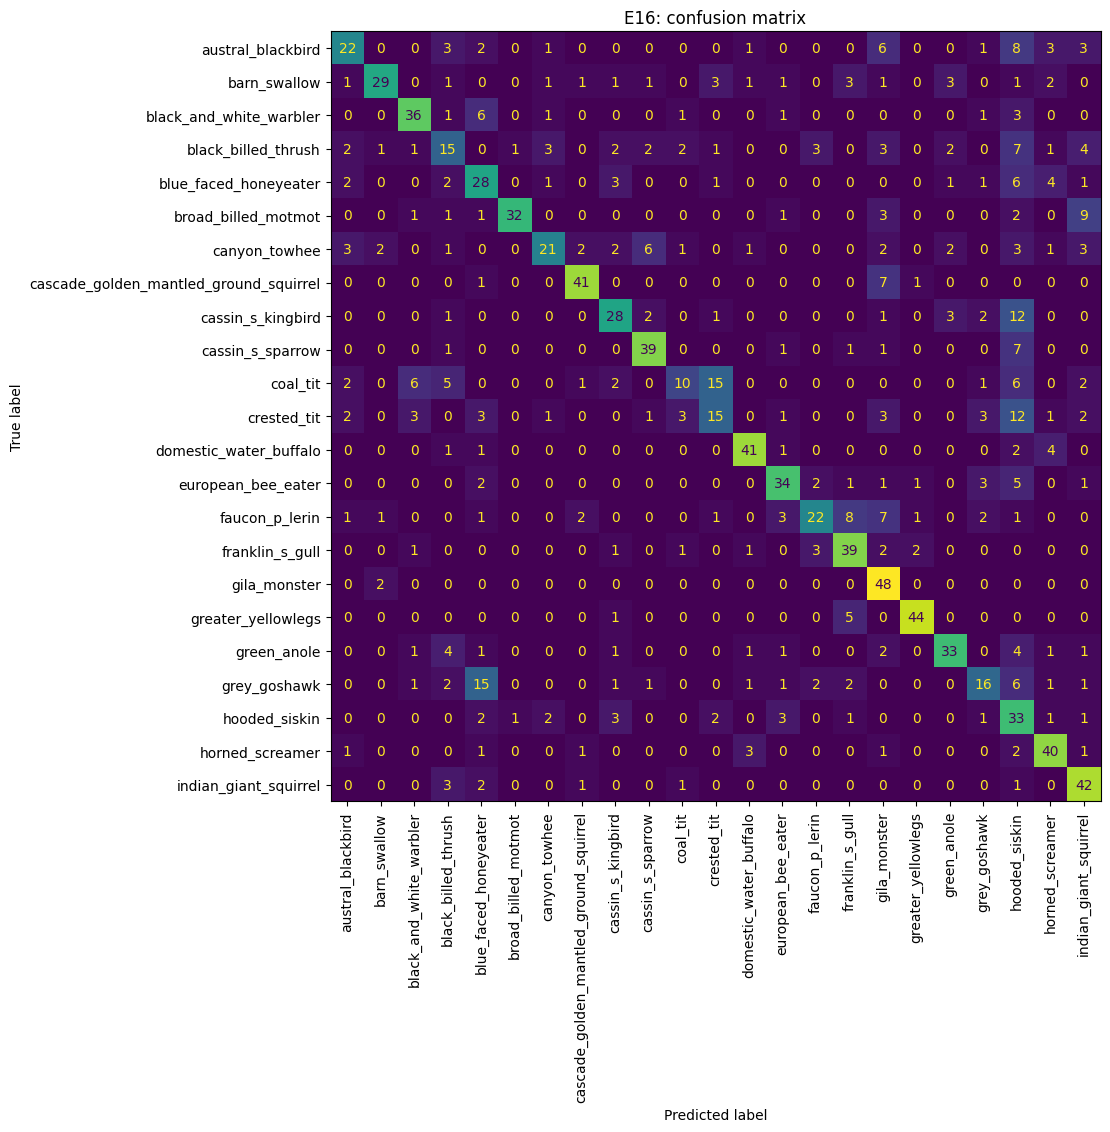

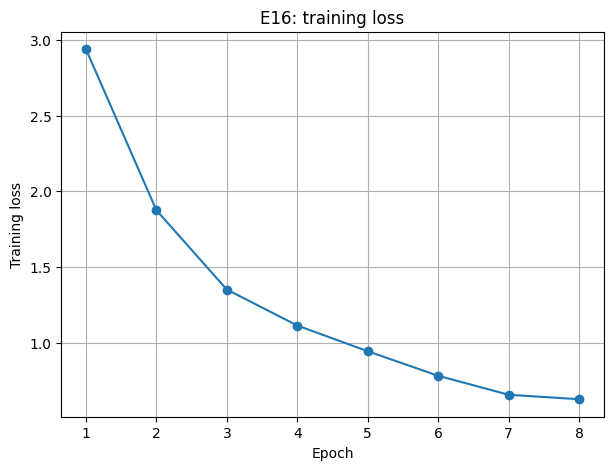

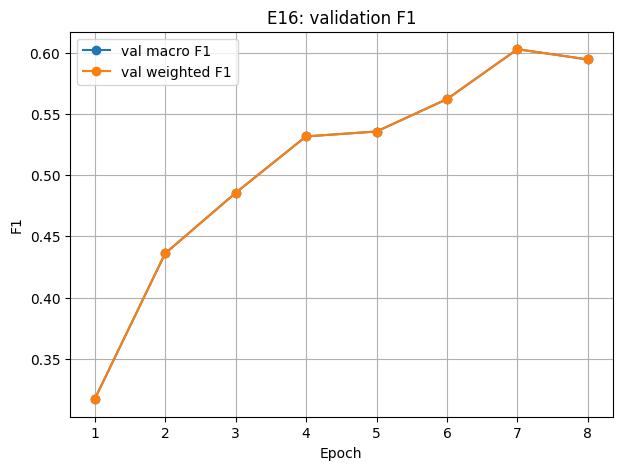

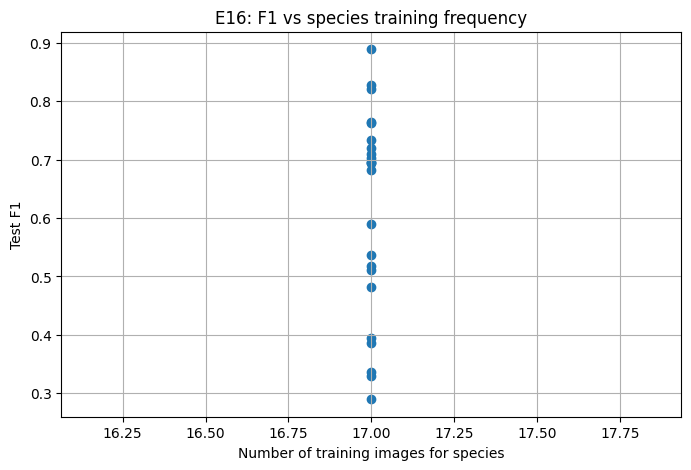

,experiment,model_type,overall_weighted_f1,species_level_weighted_f1,overall_macro_f1,blank_f1,num_train,num_test,num_classes
0,E2,frozen_backbone_finetuned_head,0.335979,0.335979,0.335979,NaN,72,1200,24
1,E8,frozen_backbone_finetuned_head,0.487756,0.487756,0.487756,NaN,207,1150,23
2,E16,frozen_backbone_finetuned_head,0.611810,0.611810,0.611810,NaN,391,1150,23


,label,train_count,test_support,precision,recall,f1,experiment
0,coal_tit,3,50,0.062500,0.02,0.030303,E2
1,black_billed_thrush,3,50,0.076923,0.04,0.052632,E2
2,crested_tit,3,50,0.157895,0.06,0.086957,E2
3,cassin_s_kingbird,3,50,0.333333,0.10,0.153846,E2
4,canyon_towhee,3,50,0.241379,0.14,0.177215,E2
...,...,...,...,...,...,...,...
65,broad_billed_motmot,17,50,0.941176,0.64,0.761905,E16
66,cassin_s_sparrow,17,50,0.750000,0.78,0.764706,E16
67,domestic_water_buffalo,17,50,0.820000,0.82,0.820000,E16
68,cascade_golden_mantled_ground_squirrel,17,50,0.836735,0.82,0.828283,E16


In [ ]:
# ============================================================
# CELL 11 — Evaluate fine-tuned models
# ============================================================

def evaluate_finetuned_model(experiment_name):
    train_df = pd.read_csv(CSV_DIR / f"{experiment_name}_train.csv")
    test_df = pd.read_csv(CSV_DIR / f"{experiment_name}_test.csv")

    ckpt = torch.load(CKPT_DIR / f"{experiment_name}_best.pt", map_location=DEVICE)

    label_to_idx = ckpt["label_to_idx"]
    idx_to_label = ckpt["idx_to_label"]
    if isinstance(list(idx_to_label.keys())[0], str):
        idx_to_label = {int(k): v for k, v in idx_to_label.items()}

    test_ds = WildlifeDataset(test_df, label_to_idx, eval_tfms)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)

    model = FrozenSpeciesNetHead(num_classes=len(label_to_idx)).to(DEVICE)
    model.load_state_dict(ckpt["model_state"])

    y_true, y_pred = predict(model, test_loader)

    metrics = compute_speciesnet_metrics(y_true, y_pred, idx_to_label)

    metrics_df = pd.DataFrame([{
        "experiment": experiment_name,
        "model_type": "frozen_backbone_finetuned_head",
        **metrics,
        "num_train": len(train_df),
        "num_test": len(test_df),
        "num_classes": len(label_to_idx),
    }])

    metrics_df.to_csv(RESULT_DIR / f"{experiment_name}_metrics.csv", index=False)

    class_f1 = per_class_f1_table(
        y_true,
        y_pred,
        idx_to_label,
        train_df["label"].value_counts().to_dict(),
    )
    class_f1.to_csv(RESULT_DIR / f"{experiment_name}_per_species_f1.csv", index=False)

    # Aggregate TP/FP/FN/TN
    agg_cm = aggregate_binary_confusion_matrix(y_true, y_pred, num_classes=len(label_to_idx))
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(agg_cm)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Predicted positive", "Predicted negative"])
    ax.set_yticklabels(["Actual positive", "Actual negative"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, agg_cm[i, j], ha="center", va="center")

    ax.set_title(f"{experiment_name}: aggregate TP/FP/FN/TN")
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"{experiment_name}_aggregate_tp_fp_fn_tn.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Standard multiclass confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=list(idx_to_label.keys()))
    fig, ax = plt.subplots(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[idx_to_label[i] for i in idx_to_label],
    )
    disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
    plt.title(f"{experiment_name}: confusion matrix")
    plt.savefig(PLOT_DIR / f"{experiment_name}_confusion_matrix.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Training curve
    hist = pd.read_csv(RESULT_DIR / f"{experiment_name}_training_history.csv")

    plt.figure(figsize=(7, 5))
    plt.plot(hist["epoch"], hist["train_loss"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title(f"{experiment_name}: training loss")
    plt.grid(True)
    plt.savefig(PLOT_DIR / f"{experiment_name}_training_curve.png", dpi=200, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(hist["epoch"], hist["val_overall_macro_f1"], marker="o", label="val macro F1")
    plt.plot(hist["epoch"], hist["val_overall_weighted_f1"], marker="o", label="val weighted F1")
    plt.xlabel("Epoch")
    plt.ylabel("F1")
    plt.title(f"{experiment_name}: validation F1")
    plt.legend()
    plt.grid(True)
    plt.savefig(PLOT_DIR / f"{experiment_name}_validation_f1_curve.png", dpi=200, bbox_inches="tight")
    plt.show()

    # F1 vs training frequency
    plt.figure(figsize=(8, 5))
    plt.scatter(class_f1["train_count"], class_f1["f1"])
    plt.xlabel("Number of training images for species")
    plt.ylabel("Test F1")
    plt.title(f"{experiment_name}: F1 vs species training frequency")
    plt.grid(True)
    plt.savefig(PLOT_DIR / f"{experiment_name}_f1_vs_species_frequency.png", dpi=200, bbox_inches="tight")
    plt.show()

    return metrics_df, class_f1

fine_tuned_metrics = []
fine_tuned_class_f1 = []

for exp_name in [f"E{n}" for n in ADDED_IMAGES_PER_SPECIES]:
    m, c = evaluate_finetuned_model(exp_name)
    fine_tuned_metrics.append(m)
    fine_tuned_class_f1.append(c.assign(experiment=exp_name))

fine_tuned_metrics_df = pd.concat(fine_tuned_metrics, ignore_index=True)
fine_tuned_class_f1_df = pd.concat(fine_tuned_class_f1, ignore_index=True)

display(fine_tuned_metrics_df)
display(fine_tuned_class_f1_df)

In [ ]:
# ============================================================
# CELL 12 — Official SpeciesNet baseline, no fine-tuning
# Evaluates official SpeciesNet directly on the same test set.
# ============================================================
# SpeciesNet official README recommends:
# python -m speciesnet.scripts.run_model --folders ... --predictions_json ...
# This automatically downloads/runs detector + classifier.

def run_official_speciesnet_on_folder(image_folder, output_json):
    cmd = [
        "python",
        "-m",
        "speciesnet.scripts.run_model",
        "--folders",
        str(image_folder),
        "--predictions_json",
        str(output_json),
    ]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

def normalize_speciesnet_string(s):
    if s is None:
        return ""
    return clean_label(str(s).split(";")[-1])

def build_eval_folder_from_test_csv(test_df, folder):
    folder.mkdir(parents=True, exist_ok=True)

    manifest_rows = []
    for i, row in test_df.reset_index(drop=True).iterrows():
        src = Path(row["path"])
        label = row["label"]
        dst = folder / f"{label}__{i:06d}{src.suffix.lower()}"

        if not dst.exists():
            try:
                os.symlink(src, dst)
            except Exception:
                import shutil
                shutil.copy2(src, dst)

        manifest_rows.append({
            "eval_path": str(dst),
            "original_path": row["path"],
            "label": label,
            "common_name": row.get("common_name", label),
            "query_name": row.get("query_name", label),
        })

    return pd.DataFrame(manifest_rows)

def normalize_speciesnet_string(s):
    if s is None:
        return ""
    return clean_label(str(s).split(";")[-1])

def parse_speciesnet_predictions(pred_json_path):
    with open(pred_json_path, "r") as f:
        data = json.load(f)

    rows = []

    for item in data.get("predictions", []):
        filepath = item.get("filepath") or item.get("file")

        classes = item.get("classifications", {}).get("classes", [])
        scores = item.get("classifications", {}).get("scores", [])

        top1_raw = item.get("prediction")
        top1_norm = normalize_speciesnet_string(top1_raw)

        top5_norm = [normalize_speciesnet_string(c) for c in classes[:5]]

        rows.append({
            "eval_path": filepath,
            "speciesnet_prediction_raw": top1_raw,
            "speciesnet_prediction_norm": top1_norm,
            "speciesnet_top5_norm": top5_norm,
            "speciesnet_score": item.get("prediction_score"),
        })

    return pd.DataFrame(rows)

def evaluate_official_speciesnet_baseline(reference_exp="E2"):
    test_df = pd.read_csv(CSV_DIR / f"{reference_exp}_test.csv")

    eval_folder = PROJECT_DIR / "official_speciesnet_eval_images"
    pred_json = RESULT_DIR / "official_speciesnet_predictions.json"

    manifest = build_eval_folder_from_test_csv(test_df, eval_folder)
    manifest.to_csv(CSV_DIR / "official_speciesnet_eval_manifest.csv", index=False)

    if not pred_json.exists():
        run_official_speciesnet_on_folder(eval_folder, pred_json)

    pred_df = parse_speciesnet_predictions(pred_json)

    merged = manifest.merge(pred_df, on="eval_path", how="left")

    labels = sorted(merged["label"].unique())
    label_to_idx = {lab: i for i, lab in enumerate(labels)}
    idx_to_label = {i: lab for lab, i in label_to_idx.items()}

    y_true = []
    y_pred = []

    for _, row in merged.iterrows():
        true_label = row["label"]
        pred_norm = row["speciesnet_prediction_norm"]
        top5_norm = row["speciesnet_top5_norm"]

        # Exact-match-only rule:
        # prediction counts as correct only if it exactly matches normalized label,
        # normalized common_name, or normalized scientific query_name.
        exact_options = {
            clean_label(true_label),
            clean_label(row.get("common_name", "")),
            clean_label(row.get("query_name", "")),
        }

        y_true.append(label_to_idx[true_label])

        if pred_norm in exact_options:
            y_pred.append(label_to_idx[true_label])
        else:
            # Map all non-exact predictions to "wrong" by assigning a different class.
            # This keeps metrics within the same label space.
            wrong_choices = [i for lab, i in label_to_idx.items() if lab != true_label]
            y_pred.append(wrong_choices[0] if wrong_choices else label_to_idx[true_label])

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    metrics = compute_speciesnet_metrics(y_true, y_pred, idx_to_label)

    metrics_df = pd.DataFrame([{
        "experiment": "official_speciesnet_no_finetuning",
        "model_type": "official_speciesnet_ensemble",
        **metrics,
        "num_train": 0,
        "num_test": len(merged),
        "num_classes": len(labels),
    }])

    metrics_df.to_csv(RESULT_DIR / "official_speciesnet_no_finetuning_metrics.csv", index=False)

    class_f1 = per_class_f1_table(y_true, y_pred, idx_to_label, train_counts={})
    class_f1.to_csv(RESULT_DIR / "official_speciesnet_no_finetuning_per_species_f1.csv", index=False)

    display(metrics_df)
    display(class_f1)

    return metrics_df, class_f1

baseline_metrics, baseline_class_f1 = evaluate_official_speciesnet_baseline(reference_exp="E2")

,experiment,model_type,overall_weighted_f1,species_level_weighted_f1,overall_macro_f1,blank_f1,num_train,num_test,num_classes
0,official_speciesnet_no_finetuning,official_speciesnet_ensemble,0.0,0.0,0.0,NaN,0,1200,24


,label,train_count,test_support,precision,recall,f1
0,austral_blackbird,0,50,0.0,0.0,0.0
1,barn_swallow,0,50,0.0,0.0,0.0
2,black_and_white_warbler,0,50,0.0,0.0,0.0
3,black_billed_thrush,0,50,0.0,0.0,0.0
4,blue_faced_honeyeater,0,50,0.0,0.0,0.0
5,broad_billed_motmot,0,50,0.0,0.0,0.0
6,canyon_towhee,0,50,0.0,0.0,0.0
7,cascade_golden_mantled_ground_squirrel,0,50,0.0,0.0,0.0
8,cassin_s_kingbird,0,50,0.0,0.0,0.0
9,cassin_s_sparrow,0,50,0.0,0.0,0.0


In [ ]:
# ============================================================
# CELL 13 — Final comparison table
# ============================================================

all_metrics = pd.concat(
    [baseline_metrics, fine_tuned_metrics_df],
    ignore_index=True,
)

all_metrics.to_csv(RESULT_DIR / "all_experiment_metric_comparison.csv", index=False)
display(all_metrics)

all_class_f1 = pd.concat(
    [
        baseline_class_f1.assign(experiment="official_speciesnet_no_finetuning"),
        fine_tuned_class_f1_df,
    ],
    ignore_index=True,
)

all_class_f1.to_csv(RESULT_DIR / "all_experiment_per_species_f1_comparison.csv", index=False)
display(all_class_f1.sort_values(["experiment", "train_count", "f1"]))

print("Saved results to:", RESULT_DIR)
print("Saved plots to:", PLOT_DIR)

,experiment,model_type,overall_weighted_f1,species_level_weighted_f1,overall_macro_f1,blank_f1,num_train,num_test,num_classes
0,official_speciesnet_no_finetuning,official_speciesnet_ensemble,0.000000,0.000000,0.000000,NaN,0,1200,24
1,E2,frozen_backbone_finetuned_head,0.335979,0.335979,0.335979,NaN,72,1200,24
2,E8,frozen_backbone_finetuned_head,0.487756,0.487756,0.487756,NaN,207,1150,23
3,E16,frozen_backbone_finetuned_head,0.611810,0.611810,0.611810,NaN,391,1150,23


,label,train_count,test_support,precision,recall,f1,experiment
71,coal_tit,17,50,0.526316,0.20,0.289855,E16
72,black_billed_thrush,17,50,0.365854,0.30,0.329670,E16
73,crested_tit,17,50,0.384615,0.30,0.337079,E16
74,hooded_siskin,17,50,0.272727,0.66,0.385965,E16
75,grey_goshawk,17,50,0.516129,0.32,0.395062,E16
...,...,...,...,...,...,...,...
19,green_anole,0,50,0.000000,0.00,0.000000,official_speciesnet_no_finetuning
20,grey_goshawk,0,50,0.000000,0.00,0.000000,official_speciesnet_no_finetuning
21,hooded_siskin,0,50,0.000000,0.00,0.000000,official_speciesnet_no_finetuning
22,horned_screamer,0,50,0.000000,0.00,0.000000,official_speciesnet_no_finetuning


Saved results to: /content/drive/MyDrive/speciesnet_experiment_iNat_bottom20/results
Saved plots to: /content/drive/MyDrive/speciesnet_experiment_iNat_bottom20/plots


In [ ]:
# ============================================================
# SPLIT SUMMARY CSV
# Creates one CSV showing train/val/test counts per species
# ============================================================

summary_rows = []

for exp_name in ["E2", "E8", "E16"]:

    train_df = pd.read_csv(CSV_DIR / f"{exp_name}_train.csv")
    val_df = pd.read_csv(CSV_DIR / f"{exp_name}_val.csv")
    test_df = pd.read_csv(CSV_DIR / f"{exp_name}_test.csv")

    all_species = sorted(
        set(train_df["label"])
        | set(val_df["label"])
        | set(test_df["label"])
    )

    for species in all_species:

        train_count = (train_df["label"] == species).sum()
        val_count = (val_df["label"] == species).sum()
        test_count = (test_df["label"] == species).sum()

        summary_rows.append({
            "experiment": exp_name,
            "species": species,
            "train_count": train_count,
            "val_count": val_count,
            "test_count": test_count,
            "total_count": train_count + val_count + test_count,
        })

split_summary = pd.DataFrame(summary_rows)

split_summary.to_csv(
    RESULT_DIR / "species_train_val_test_split_summary.csv",
    index=False,
)

display(split_summary)

print(
    "Saved:",
    RESULT_DIR / "species_train_val_test_split_summary.csv"
)

,experiment,species,train_count,val_count,test_count,total_count
0,E2,austral_blackbird,3,20,50,73
1,E2,barn_swallow,3,20,50,73
2,E2,black_and_white_warbler,3,20,50,73
3,E2,black_billed_thrush,3,20,50,73
4,E2,blue_faced_honeyeater,3,20,50,73
...,...,...,...,...,...,...
65,E16,green_anole,17,20,50,87
66,E16,grey_goshawk,17,20,50,87
67,E16,hooded_siskin,17,20,50,87
68,E16,horned_screamer,17,20,50,87


Saved: /content/drive/MyDrive/speciesnet_experiment_iNat_bottom20/results/species_train_val_test_split_summary.csv
